# Hamming-Controlled Barrier vs Overlap Length

Investigates whether the **max z-score distance barrier** along a GA-optimised mutation path increases with overlap length, **controlling for Hamming distance**.

## Strategy: Pool-then-Search
1. For each overlap, generate a **pool** of converged sequences (|z1| < 1.0 AND |z2| < 1.0)
2. Search all O(n²) pairs for those near the **target Hamming distance**
3. Select N non-overlapping pairs (each sequence used at most once)
4. Run GA on each pair to find the optimal mutation ordering
5. Record the max barrier along the path

This decouples convergence filtering from pair selection, giving much more reliable results than the earlier approach.

In [124]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import pickle
import json
import os
import warnings
from multiprocessing import Pool
from tqdm.auto import tqdm
import seaborn as sns

sns.set_theme(style="ticks", palette="muted")
sns.set_context("paper", font_scale=1.2)

import overlappingGenes as og
from ga_worker import (
    generate_single_sequence,
    run_ga_on_pair,
    GeneticPathFinder,
    find_pair_with_target_hamming,
    hamming_distance,
    get_path_energies
)

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('viridis')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

np.random.seed(42)

In [125]:
# ===================== CONFIGURATION =====================

# Protein pair
PROTEIN_1 = 'PF02518'
PROTEIN_2 = 'PF00271'

# Tag used in all output filenames
PAIR_TAG = f"{PROTEIN_1}_{PROTEIN_2}"

# Overlap sweep
OVERLAP_START = 180
OVERLAP_STOP = 182
OVERLAP_STEP = 1

# Convergence filter: both |z1| and |z2| must be below this
Z_SCORE_THRESHOLD = 1.0

# Phase 1: sequence pool generation
# Defaults — used for any overlap not listed in the overrides below
MC_RUNS_DEFAULT = 2_000
MC_ITERS_DEFAULT = 250_000

# Per-overlap overrides — add entries here for overlaps that need more compute
# e.g. after a first run shows high overlaps need more sequences or longer MC
MC_RUNS_OVERRIDE = {
    #205: 10_000,
    #229: 10_000,
    #253: 10_000,
    #277: 10_000,
}
MC_ITERS_OVERRIDE = {
    #205: 500_000,
    #229: 500_000,
    #253: 500_000,
    #277: 500_000,
}

# Hamming distance control
TARGET_HAMMING = 240
HAMMING_TOLERANCE = 20

# Phase 2: GA trials
N_PAIRS_PER_OVERLAP = 10         # non-overlapping pairs per overlap
GA_POPULATION = 100
GA_GENERATIONS = 200

# Parallelism
N_WORKERS_PHASE1 = 12
N_WORKERS_PHASE2 = 4

# Output files — pair name baked in
CHECKPOINT_FILE = f'hamming_controlled_checkpoint_{PAIR_TAG}.pkl'
RESULTS_CSV = f'hamming_controlled_results_{PAIR_TAG}.csv'

overlaps = list(range(OVERLAP_START, OVERLAP_STOP + 1, OVERLAP_STEP))
print(f"Pair: {PAIR_TAG}")
print(f"Overlaps to test: {overlaps}")
print(f"Total overlaps: {len(overlaps)}")
print(f"\nPer-overlap settings:")
for ov in overlaps:
    runs = MC_RUNS_OVERRIDE.get(ov, MC_RUNS_DEFAULT)
    iters = MC_ITERS_OVERRIDE.get(ov, MC_ITERS_DEFAULT)
    tag = " (override)" if ov in MC_RUNS_OVERRIDE or ov in MC_ITERS_OVERRIDE else ""
    print(f"  ov={ov:3d}: {runs:,} runs x {iters:,} iters{tag}")

Pair: PF02518_PF00271
Overlaps to test: [180, 181, 182]
Total overlaps: 3

Per-overlap settings:
  ov=180: 2,000 runs x 250,000 iters
  ov=181: 2,000 runs x 250,000 iters
  ov=182: 2,000 runs x 250,000 iters


In [126]:
# ===================== LOAD DCA PARAMETERS =====================

print(f"Loading DCA parameters for {PROTEIN_1}...")
Jvec_1, hvec_1 = og.extract_params(f'bmDCA/{PROTEIN_1}/{PROTEIN_1}_params.dat')
nat_energies_1 = og.load_natural_energies(f'bmDCA/{PROTEIN_1}/{PROTEIN_1}_naturalenergies.txt')
mean_e1, std_e1 = np.mean(nat_energies_1), np.std(nat_energies_1)

print(f"Loading DCA parameters for {PROTEIN_2}...")
Jvec_2, hvec_2 = og.extract_params(f'bmDCA/{PROTEIN_2}/{PROTEIN_2}_params.dat')
nat_energies_2 = og.load_natural_energies(f'bmDCA/{PROTEIN_2}/{PROTEIN_2}_naturalenergies.txt')
mean_e2, std_e2 = np.mean(nat_energies_2), np.std(nat_energies_2)

prot1_len = len(hvec_1) // 21
prot2_len = len(hvec_2) // 21
print(f"\nProtein 1 length: {prot1_len} AA")
print(f"Protein 2 length: {prot2_len} AA")

# Load optimal temperatures
with open('optimal_temperatures.json', 'r') as f:
    optimal_temps = json.load(f)

mc_temp_1 = optimal_temps[PROTEIN_1]
mc_temp_2 = optimal_temps[PROTEIN_2]
print(f"MC temperature {PROTEIN_1}: {mc_temp_1}")
print(f"MC temperature {PROTEIN_2}: {mc_temp_2}")

print(f"\nNatural energy stats:")
print(f"  {PROTEIN_1}: mean={mean_e1:.2f}, std={std_e1:.2f}")
print(f"  {PROTEIN_2}: mean={mean_e2:.2f}, std={std_e2:.2f}")

Loading DCA parameters for PF02518...
Loading DCA parameters for PF00271...

Protein 1 length: 101 AA
Protein 2 length: 95 AA
MC temperature PF02518: 1.068391
MC temperature PF00271: 0.872126

Natural energy stats:
  PF02518: mean=186.84, std=26.05
  PF00271: mean=149.58, std=27.18


In [127]:
# ===================== NUMBA WARMUP =====================

print("Warming up Numba JIT...")
warmup_overlap = 12
warmup_seq = og.initial_seq_no_stops(prot1_len, prot2_len, warmup_overlap, quiet=True)
_ = og.overlapped_sequence_generator_int(
    (Jvec_1, hvec_1), (Jvec_2, hvec_2), warmup_seq,
    T1=mc_temp_1, T2=mc_temp_2,
    numberofiterations=100, quiet=True, whentosave=100.0,
    nat_mean1=mean_e1, nat_mean2=mean_e2,
    nat_std1=std_e1, nat_std2=std_e2,
    use_z_score=True
)
print("Warmup complete.")

Warming up Numba JIT...
Warmup complete.


In [128]:
# ===================== CHECKPOINT RESUME =====================

if os.path.exists(CHECKPOINT_FILE):
    with open(CHECKPOINT_FILE, 'rb') as f:
        checkpoint = pickle.load(f)
    all_results = checkpoint['all_results']
    completed_overlaps = checkpoint['completed_overlaps']
    pool_cache = checkpoint['pool_cache']
    print(f"Resumed from checkpoint: {len(completed_overlaps)} overlaps completed")
    print(f"  Completed: {sorted(completed_overlaps)}")
else:
    all_results = []
    completed_overlaps = set()
    pool_cache = {}  # overlap -> list of (sequence, z1, z2)
    print("Starting fresh (no checkpoint found).")

Starting fresh (no checkpoint found).


In [129]:
# ===================== HELPER FUNCTIONS =====================

def compute_reading_frame(overlap):
    """Compute the reading frame for a given overlap length.
    Consistent with Large Scale notebooks:
      overlap % 3 == 0  ->  Frame 0  (in-frame)
      overlap % 3 == 1  ->  Frame +1 (shifted by 1nt)
      overlap % 3 == 2  ->  Frame +2 (shifted by 2nt)"""
    return overlap % 3


def filter_converged(sequences_with_energies, threshold=Z_SCORE_THRESHOLD):
    """Filter sequences to those where both |z1| < threshold AND |z2| < threshold.
    Input: list of (sequence_str, best_energies_array)
    Returns: list of (sequence_str, z1, z2)"""
    converged = []
    for seq, energies in sequences_with_energies:
        z1 = (energies[0] - mean_e1) / std_e1
        z2 = (energies[1] - mean_e2) / std_e2
        if abs(z1) < threshold and abs(z2) < threshold:
            converged.append((seq, z1, z2))
    return converged


def select_n_pairs(sequences, n, target_h, tolerance):
    """Greedy non-overlapping pair selection using vectorised Hamming distances.
    Converts sequences to a 2D uint8 array and computes all pairwise Hamming
    distances via broadcasting, then greedily picks non-overlapping pairs
    closest to target_h.
    Returns: list of (i, j, hamming_dist) tuples."""
    n_seqs = len(sequences)
    if n_seqs < 2:
        return []

    # Convert all sequences to a 2D numpy array for vectorised comparison
    seq_len = len(sequences[0][0])
    arr = np.empty((n_seqs, seq_len), dtype='U1')
    for i, (seq, _, _) in enumerate(sequences):
        arr[i] = list(seq)

    # Compute upper triangle of pairwise Hamming distances
    # Process in chunks to limit memory: compare each row against all later rows
    candidates = []
    for i in range(n_seqs):
        # arr[i] vs arr[i+1:] — vectorised across all j > i
        diffs = (arr[i] != arr[i+1:]).sum(axis=1)  # shape (n_seqs - i - 1,)
        for k, h in enumerate(diffs):
            j = i + 1 + k
            diff = abs(int(h) - target_h)
            if diff <= tolerance:
                candidates.append((diff, i, j, int(h)))

    # Sort by closeness to target
    candidates.sort(key=lambda x: x[0])

    # Greedy non-overlapping selection
    used = set()
    selected = []
    for diff, i, j, h in candidates:
        if i not in used and j not in used:
            selected.append((i, j, h))
            used.add(i)
            used.add(j)
            if len(selected) >= n:
                break

    return selected


# Print reading frame diagnostic
print("Reading frame per overlap:")
for ov in overlaps:
    rf = compute_reading_frame(ov)
    print(f"  overlap={ov:3d} -> Frame +{rf}")

unique_frames = set(compute_reading_frame(ov) for ov in overlaps)
if len(unique_frames) == 1:
    frame_val = unique_frames.pop()
    print(f"\nWARNING: All overlaps land in Frame +{frame_val}. "
          f"To sample multiple frames, use an OVERLAP_STEP that is not "
          f"divisible by 3.")

Reading frame per overlap:
  overlap=180 -> Frame +0
  overlap=181 -> Frame +1
  overlap=182 -> Frame +2


In [ ]:
# ===================== MAIN LOOP =====================

seed_counter = 1000  # base seed for reproducibility

for overlap in overlaps:
    if overlap in completed_overlaps:
        print(f"\nOverlap {overlap}: already completed, skipping.")
        continue

    reading_frame = compute_reading_frame(overlap)
    mc_runs = MC_RUNS_OVERRIDE.get(overlap, MC_RUNS_DEFAULT)
    mc_iters = MC_ITERS_OVERRIDE.get(overlap, MC_ITERS_DEFAULT)

    print(f"\n{'='*60}")
    print(f"Overlap {overlap} (Frame +{reading_frame}) — {mc_runs:,} runs x {mc_iters:,} iters")
    print(f"{'='*60}")

    # ------ Phase 1: Generate converged sequence pool ------
    if overlap in pool_cache and len(pool_cache[overlap]) >= 2:
        pool = pool_cache[overlap]
        print(f"  Phase 1: Using cached pool ({len(pool)} converged sequences)")
    else:
        print(f"  Phase 1: Generating {mc_runs} sequences...")

        args_list = []
        for i in range(mc_runs):
            seed_counter += 1
            args_list.append((
                overlap, 0, i, seed_counter,
                Jvec_1, hvec_1, Jvec_2, hvec_2,
                prot1_len, prot2_len,
                mc_iters, mc_temp_1, mc_temp_2,
                mean_e1, mean_e2, std_e1, std_e2, True  # z_score=True
            ))

        with Pool(processes=N_WORKERS_PHASE1) as p:
            results = list(tqdm(
                p.imap_unordered(generate_single_sequence, args_list),
                total=len(args_list),
                desc=f"  Pool gen (ov={overlap})",
                leave=False
            ))

        # Filter for convergence
        raw = [(r['sequence'], r['energies']) for r in results if r['success']]
        pool = filter_converged(raw)
        pool_cache[overlap] = pool

        print(f"  Phase 1 done: {len(raw)} successful, "
              f"{len(pool)} converged (|z|<{Z_SCORE_THRESHOLD})")

    # ------ Pair Selection ------
    if len(pool) < 2:
        print(f"  SKIPPING: not enough converged sequences ({len(pool)})")
        completed_overlaps.add(overlap)
        continue

    selected_pairs = select_n_pairs(pool, N_PAIRS_PER_OVERLAP,
                                     TARGET_HAMMING, HAMMING_TOLERANCE)
    print(f"  Pair selection: found {len(selected_pairs)} non-overlapping pairs "
          f"at Hamming {TARGET_HAMMING}+/-{HAMMING_TOLERANCE}")

    if len(selected_pairs) == 0:
        # Report distribution of available Hamming distances
        all_h = []
        for i in range(len(pool)):
            for j in range(i+1, min(i+50, len(pool))):  # sample
                all_h.append(hamming_distance(pool[i][0], pool[j][0]))
        if all_h:
            print(f"  Available Hamming range: {min(all_h)}-{max(all_h)}, "
                  f"median={np.median(all_h):.0f}")
        print(f"  SKIPPING: no pairs found within tolerance.")
        completed_overlaps.add(overlap)
        continue

    for i, j, h in selected_pairs:
        print(f"    Pair: seq {i} <-> seq {j}, Hamming={h}")

    # ------ Phase 2: Run GA on selected pairs ------
    print(f"  Phase 2: Running GA on {len(selected_pairs)} pairs...")

    ga_args_list = []
    for trial_idx, (i, j, h) in enumerate(selected_pairs):
        seed_counter += 1
        ga_args_list.append((
            pool[i][0], pool[j][0],  # seq_start, seq_end
            Jvec_1, hvec_1, Jvec_2, hvec_2,
            prot1_len, prot2_len,
            mean_e1, mean_e2, std_e1, std_e2, True,  # z_score
            GA_POPULATION, GA_GENERATIONS,
            overlap, trial_idx, h, reading_frame, seed_counter
        ))

    with Pool(processes=N_WORKERS_PHASE2) as p:
        ga_results = list(tqdm(
            p.imap_unordered(run_ga_on_pair, ga_args_list),
            total=len(ga_args_list),
            desc=f"  GA (ov={overlap})",
            leave=False
        ))

    # Collect results
    n_success = sum(1 for r in ga_results if r['success'])
    barriers = [r['max_barrier'] for r in ga_results if r['success']]
    print(f"  Phase 2 done: {n_success}/{len(ga_results)} successful")
    if barriers:
        print(f"  Barriers: mean={np.mean(barriers):.3f}, "
              f"std={np.std(barriers):.3f}, "
              f"range=[{min(barriers):.3f}, {max(barriers):.3f}]")

    all_results.extend(ga_results)
    completed_overlaps.add(overlap)

    # ------ Checkpoint ------
    with open(CHECKPOINT_FILE, 'wb') as f:
        pickle.dump({
            'all_results': all_results,
            'completed_overlaps': completed_overlaps,
            'pool_cache': pool_cache
        }, f)
    print(f"  Checkpoint saved ({len(completed_overlaps)}/{len(overlaps)} overlaps done).")

print(f"\n{'='*60}")
print(f"All overlaps processed. Total results: {len(all_results)}")


Overlap 180 (Frame +0) — 2,000 runs x 250,000 iters
  Phase 1: Generating 2000 sequences...


  Phase 1 done: 2000 successful, 1924 converged (|z|<1.0)
  Pair selection: found 10 non-overlapping pairs at Hamming 240+/-20
    Pair: seq 19 <-> seq 483, Hamming=241
    Pair: seq 303 <-> seq 1001, Hamming=239
    Pair: seq 351 <-> seq 1150, Hamming=239
    Pair: seq 884 <-> seq 1790, Hamming=239
    Pair: seq 942 <-> seq 1120, Hamming=239
    Pair: seq 1018 <-> seq 1674, Hamming=239
    Pair: seq 1111 <-> seq 1331, Hamming=241
    Pair: seq 1206 <-> seq 1704, Hamming=241
    Pair: seq 1633 <-> seq 1748, Hamming=239
    Pair: seq 123 <-> seq 380, Hamming=238
  Phase 2: Running GA on 10 pairs...


  GA (ov=180):   0%|          | 0/10 [00:00<?, ?it/s]

In [ ]:
# ===================== BUILD DATAFRAME =====================

rows = []
for r in all_results:
    rows.append({
        'protein_1': PROTEIN_1,
        'protein_2': PROTEIN_2,
        'overlap': r['overlap'],
        'trial_idx': r['trial_idx'],
        'hamming_dist': r['hamming_dist'],
        'reading_frame': r['reading_frame'],
        'max_barrier': r['max_barrier'],
        'n_mutations': r['n_mutations'],
        'start_z1': r['start_z1'],
        'start_z2': r['start_z2'],
        'end_z1': r['end_z1'],
        'end_z2': r['end_z2'],
        'success': r['success'],
        'error': r['error']
    })

df = pd.DataFrame(rows)
df_success = df[df['success']].copy()

print(f"Total results: {len(df)}")
print(f"Successful: {len(df_success)}")
print(f"Failed: {len(df) - len(df_success)}")

if len(df_success) > 0:
    df_success.to_csv(RESULTS_CSV, index=False)
    print(f"\nSaved to {RESULTS_CSV}")
    display(df_success.describe())
else:
    print("No successful results to save.")

KeyError: 'success'

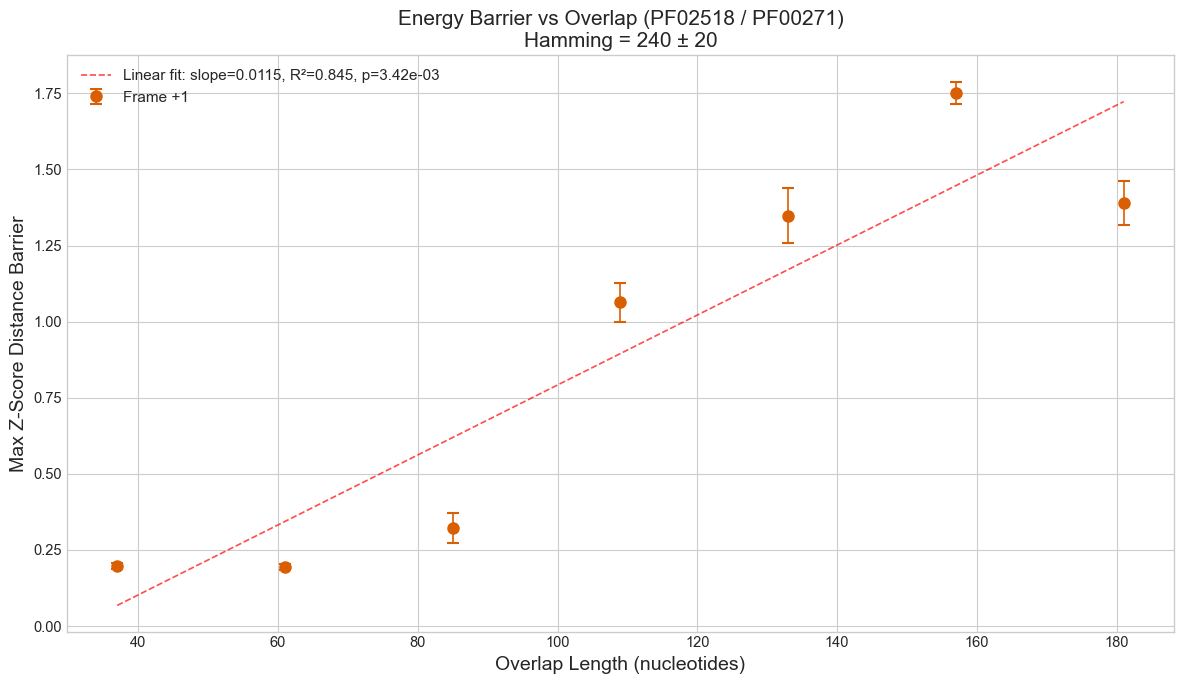


Linear regression: slope=0.01149, R²=0.8448, p=3.42e-03


In [ ]:
# ===================== MAIN PLOT: Barrier vs Overlap =====================

if len(df_success) > 0:
    fig, ax = plt.subplots(figsize=(12, 7))

    # Group by overlap for error bars
    grouped = df_success.groupby('overlap')['max_barrier']
    ov_vals = grouped.mean().index.values
    means = grouped.mean().values
    stds = grouped.std().values
    counts = grouped.count().values
    sems = stds / np.sqrt(counts)

    # Color by reading frame
    frame_colors = {0: '#1b9e77', 1: '#d95f02', 2: '#7570b3'}
    frame_labels_added = set()

    for ov, m, sem in zip(ov_vals, means, sems):
        rf = compute_reading_frame(ov)
        color = frame_colors.get(rf, 'gray')
        label = f'Frame +{rf}' if rf not in frame_labels_added else None
        ax.errorbar(ov, m, yerr=sem, fmt='o', color=color, markersize=8,
                    capsize=4, capthick=1.5, label=label)
        frame_labels_added.add(rf)

    # Linear regression
    from scipy import stats as sp_stats
    slope, intercept, r_value, p_value, std_err = sp_stats.linregress(ov_vals, means)
    x_fit = np.linspace(ov_vals.min(), ov_vals.max(), 100)
    ax.plot(x_fit, slope * x_fit + intercept, '--', color='red', alpha=0.7,
            label=f'Linear fit: slope={slope:.4f}, R\u00b2={r_value**2:.3f}, p={p_value:.2e}')

    ax.set_xlabel('Overlap Length (nucleotides)', fontsize=14)
    ax.set_ylabel('Max Z-Score Distance Barrier', fontsize=14)
    ax.set_title(f'Energy Barrier vs Overlap ({PROTEIN_1} / {PROTEIN_2})\n'
                 f'Hamming = {TARGET_HAMMING} \u00b1 {HAMMING_TOLERANCE}', fontsize=15)
    ax.legend(fontsize=11)
    plt.tight_layout()
    plt.savefig(f'hamming_controlled_barrier_vs_overlap_{PAIR_TAG}.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"\nLinear regression: slope={slope:.5f}, R\u00b2={r_value**2:.4f}, p={p_value:.2e}")
else:
    print("No data to plot.")

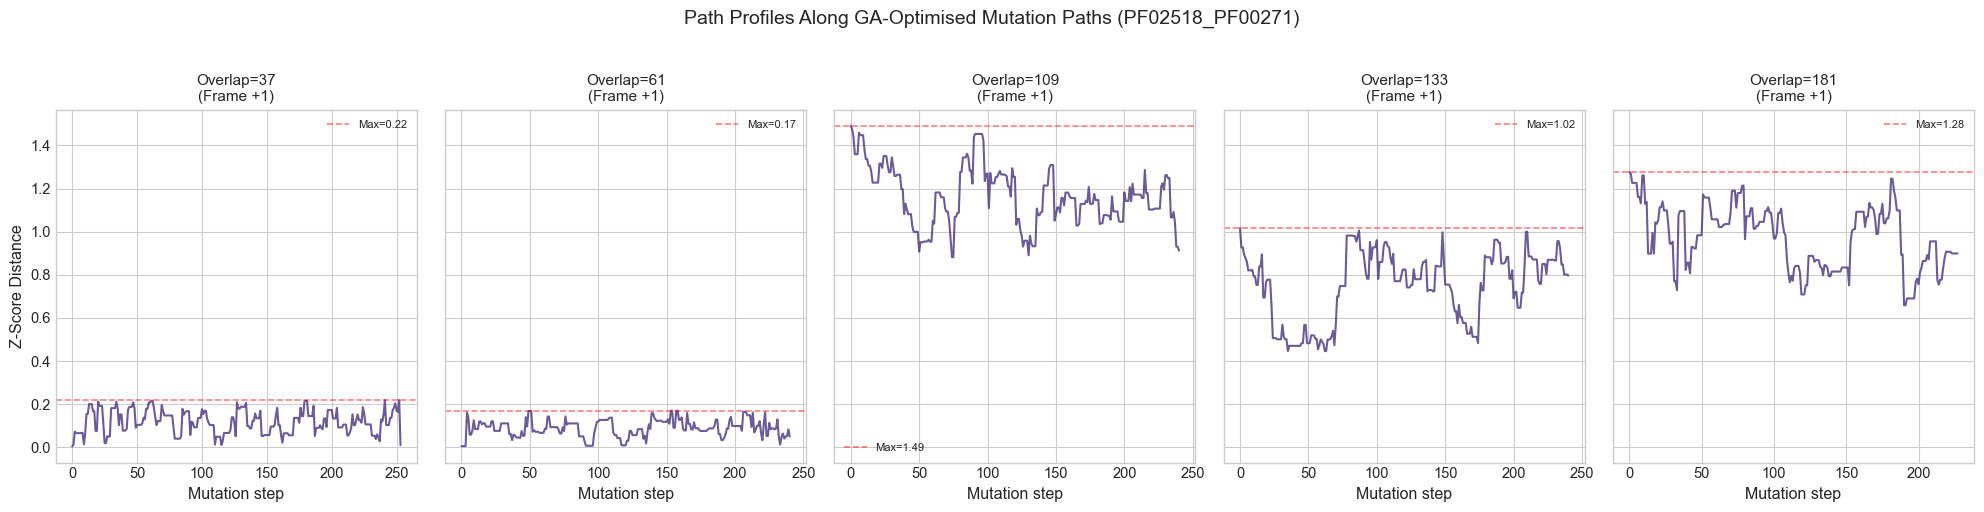

In [ ]:
# ===================== PATH PROFILES =====================

if len(all_results) > 0:
    # Select ~5 representative overlap values
    successful_overlaps = sorted(df_success['overlap'].unique())
    if len(successful_overlaps) >= 5:
        indices = np.linspace(0, len(successful_overlaps) - 1, 5, dtype=int)
        representative_overlaps = [successful_overlaps[i] for i in indices]
    else:
        representative_overlaps = successful_overlaps

    fig, axes = plt.subplots(1, len(representative_overlaps),
                              figsize=(4 * len(representative_overlaps), 5),
                              sharey=True)
    if len(representative_overlaps) == 1:
        axes = [axes]

    for ax, ov in zip(axes, representative_overlaps):
        # Find first successful result for this overlap that has path data
        for r in all_results:
            if r['overlap'] == ov and r['success'] and len(r['path_distances']) > 1:
                dists = np.array(r['path_distances'])
                steps = np.arange(len(dists))
                ax.plot(steps, dists, '-', alpha=0.8, linewidth=1.5)
                ax.axhline(y=r['max_barrier'], color='red', linestyle='--',
                           alpha=0.5, label=f'Max={r["max_barrier"]:.2f}')
                break

        rf = compute_reading_frame(ov)
        ax.set_title(f'Overlap={ov}\n(Frame +{rf})', fontsize=11)
        ax.set_xlabel('Mutation step')
        ax.legend(fontsize=8)

    axes[0].set_ylabel('Z-Score Distance')
    fig.suptitle(f'Path Profiles Along GA-Optimised Mutation Paths ({PAIR_TAG})',
                 fontsize=14, y=1.02)
    plt.tight_layout()
    plt.savefig(f'hamming_controlled_path_profiles_{PAIR_TAG}.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("No results for path profiles.")

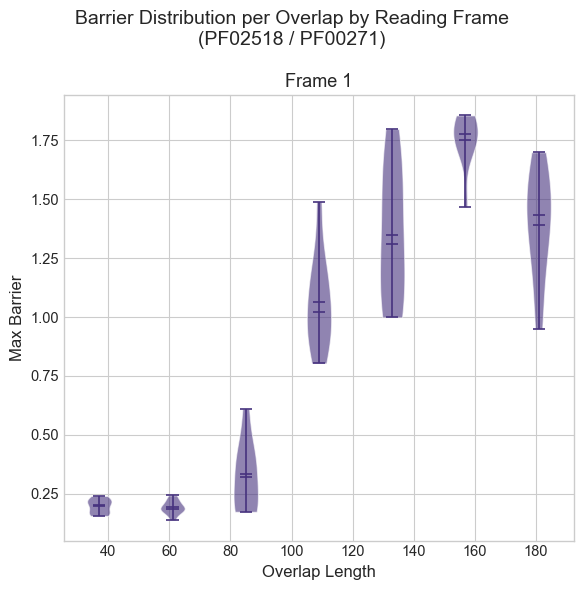

In [ ]:
# ===================== PER-FRAME BREAKDOWN =====================

if len(df_success) > 0:
    unique_frames = sorted(df_success['reading_frame'].unique())
    n_frames = len(unique_frames)

    fig, axes = plt.subplots(1, max(n_frames, 1), figsize=(6 * max(n_frames, 1), 6),
                              sharey=True, squeeze=False)
    axes = axes[0]

    for idx, frame in enumerate(unique_frames):
        ax = axes[idx]
        frame_data = df_success[df_success['reading_frame'] == frame]

        overlaps_in_frame = sorted(frame_data['overlap'].unique())
        violin_data = [frame_data[frame_data['overlap'] == ov]['max_barrier'].values
                       for ov in overlaps_in_frame]

        # Filter out empty arrays
        valid = [(ov, d) for ov, d in zip(overlaps_in_frame, violin_data) if len(d) > 0]
        if valid:
            positions, data = zip(*valid)
            parts = ax.violinplot(data, positions=positions, widths=8,
                                  showmeans=True, showmedians=True)
            for pc in parts['bodies']:
                pc.set_alpha(0.6)

        ax.set_title(f'Frame {frame}', fontsize=13)
        ax.set_xlabel('Overlap Length', fontsize=12)
        if idx == 0:
            ax.set_ylabel('Max Barrier', fontsize=12)

    fig.suptitle(f'Barrier Distribution per Overlap by Reading Frame\n'
                 f'({PROTEIN_1} / {PROTEIN_2})', fontsize=14)
    plt.tight_layout()
    plt.savefig(f'hamming_controlled_per_frame_{PAIR_TAG}.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("No data for per-frame breakdown.")

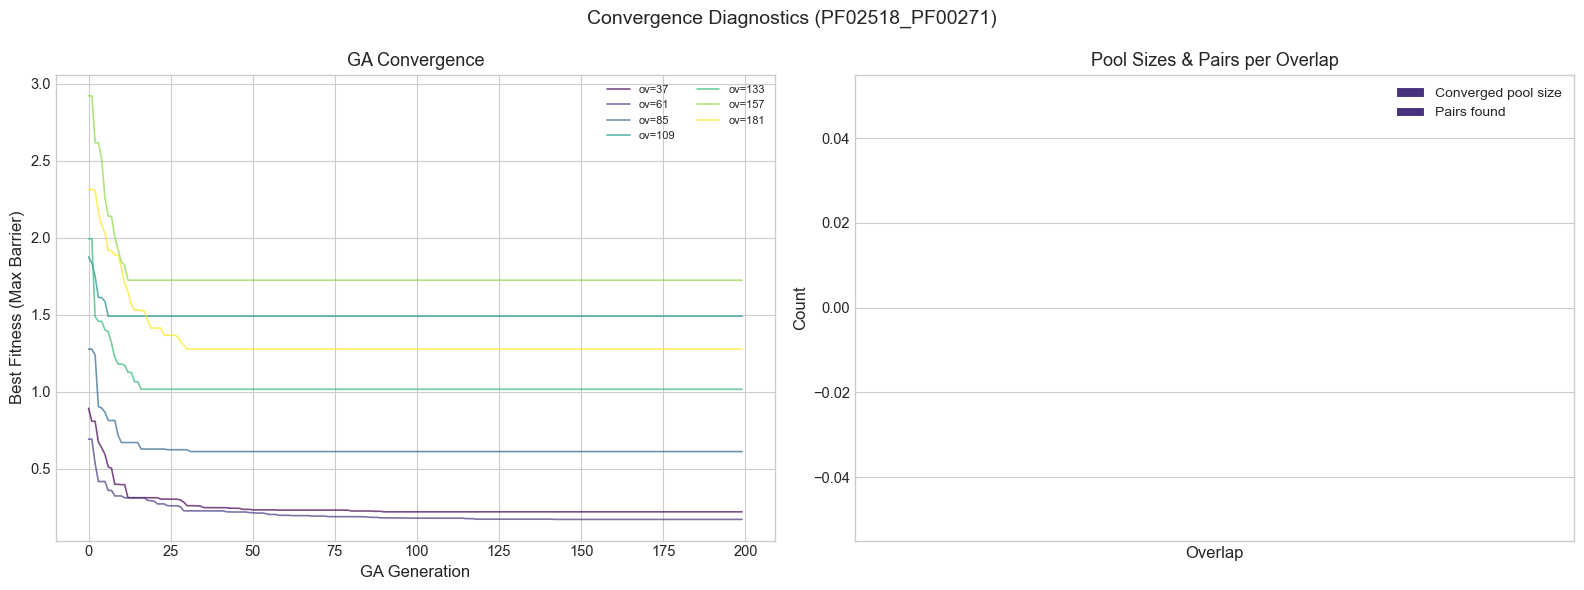

In [ ]:
# ===================== CONVERGENCE DIAGNOSTICS =====================

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# --- Left: GA fitness history curves ---
if len(all_results) > 0:
    successful_overlaps = sorted(df_success['overlap'].unique())
    cmap = plt.cm.viridis(np.linspace(0, 1, len(successful_overlaps)))

    for ov_idx, ov in enumerate(successful_overlaps):
        # Plot first successful trial's fitness history for each overlap
        for r in all_results:
            if r['overlap'] == ov and r['success'] and len(r['fitness_history']) > 0:
                ax1.plot(r['fitness_history'], color=cmap[ov_idx], alpha=0.7,
                         label=f'ov={ov}' if ov_idx < 8 else None)
                break

    ax1.set_xlabel('GA Generation', fontsize=12)
    ax1.set_ylabel('Best Fitness (Max Barrier)', fontsize=12)
    ax1.set_title('GA Convergence', fontsize=13)
    ax1.legend(fontsize=8, ncol=2, loc='upper right')

# --- Right: Pool sizes and pairs found ---
pool_sizes = []
pairs_found = []
ov_labels = []

for ov in overlaps:
    pool_size = len(pool_cache.get(ov, []))
    n_pairs = len([r for r in all_results
                   if r['overlap'] == ov and r['success']])
    pool_sizes.append(pool_size)
    pairs_found.append(n_pairs)
    ov_labels.append(str(ov))

x = np.arange(len(ov_labels))
width = 0.35
ax2.bar(x - width/2, pool_sizes, width, label='Converged pool size', alpha=0.7)
ax2.bar(x + width/2, pairs_found, width, label='Pairs found', alpha=0.7)
ax2.set_xticks(x)
ax2.set_xticklabels(ov_labels, rotation=45, ha='right', fontsize=8)
ax2.set_xlabel('Overlap', fontsize=12)
ax2.set_ylabel('Count', fontsize=12)
ax2.set_title('Pool Sizes & Pairs per Overlap', fontsize=13)
ax2.legend(fontsize=10)

fig.suptitle(f'Convergence Diagnostics ({PAIR_TAG})', fontsize=14)
plt.tight_layout()
plt.savefig(f'hamming_controlled_diagnostics_{PAIR_TAG}.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ===================== STATISTICAL SUMMARY =====================

if len(df_success) > 0:
    from scipy import stats as sp_stats

    print("=" * 60)
    print("STATISTICAL SUMMARY")
    print("=" * 60)

    # Overall regression
    slope, intercept, r_value, p_value, std_err = sp_stats.linregress(
        df_success['overlap'], df_success['max_barrier'])
    print(f"\nOverall linear regression:")
    print(f"  slope     = {slope:.6f} +/- {std_err:.6f}")
    print(f"  intercept = {intercept:.4f}")
    print(f"  R\u00b2        = {r_value**2:.4f}")
    print(f"  p-value   = {p_value:.2e}")
    print(f"  N         = {len(df_success)}")

    # Per-frame regression
    print(f"\nPer-frame regressions:")
    for frame in sorted(df_success['reading_frame'].unique()):
        fdata = df_success[df_success['reading_frame'] == frame]
        if len(fdata) >= 3 and fdata['overlap'].nunique() >= 2:
            s, i, r, p, se = sp_stats.linregress(fdata['overlap'], fdata['max_barrier'])
            print(f"  Frame {frame}: slope={s:.6f}+/-{se:.6f}, "
                  f"R\u00b2={r**2:.4f}, p={p:.2e}, N={len(fdata)}")
        else:
            print(f"  Frame {frame}: insufficient data (N={len(fdata)})")

    # Summary table
    print(f"\nSummary table:")
    summary = df_success.groupby('overlap').agg(
        barrier_mean=('max_barrier', 'mean'),
        barrier_std=('max_barrier', 'std'),
        barrier_min=('max_barrier', 'min'),
        barrier_max=('max_barrier', 'max'),
        hamming_mean=('hamming_dist', 'mean'),
        n_trials=('max_barrier', 'count'),
        reading_frame=('reading_frame', 'first')
    ).round(4)
    display(summary)

    # Hamming distance verification
    print(f"\nHamming distance verification:")
    print(f"  Target: {TARGET_HAMMING} +/- {HAMMING_TOLERANCE}")
    print(f"  Actual range: [{df_success['hamming_dist'].min()}, {df_success['hamming_dist'].max()}]")
    print(f"  Actual mean: {df_success['hamming_dist'].mean():.1f}")
else:
    print("No successful results for statistical summary.")

STATISTICAL SUMMARY

Overall linear regression:
  slope     = 0.011446 +/- 0.000728
  intercept = -0.3480
  R²        = 0.7868
  p-value   = 3.58e-24
  N         = 69

Per-frame regressions:
  Frame 1: slope=0.011446+/-0.000728, R²=0.7868, p=3.58e-24, N=69

Summary table:


,barrier_mean,barrier_std,barrier_min,barrier_max,hamming_mean,n_trials,reading_frame
overlap,,,,,,,
37,0.1978,0.0307,0.1559,0.2409,253.6,10,1
61,0.1930,0.0297,0.1376,0.2436,240.0,10,1
85,0.3225,0.1489,0.1735,0.6111,240.0,9,1
109,1.0630,0.2004,0.8036,1.4906,240.0,10,1
133,1.3482,0.2849,0.9988,1.7984,240.0,10,1
157,1.7525,0.1144,1.4668,1.8562,240.0,10,1
181,1.3902,0.2309,0.9503,1.7000,227.0,10,1



Hamming distance verification:
  Target: 240 +/- 20
  Actual range: [224, 255]
  Actual mean: 240.1
